`EDA = Exploratory Data Analysis`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
EDA_DIR = Path("artifacts/eda")
EDA_DIR.mkdir(parents=True, exist_ok=True) 

In [4]:
train = pd.read_csv("artifacts/train.csv")
print("Training data loaded successfully.")
print("Shape:", train.shape)

Training data loaded successfully.
Shape: (67533, 25)


In [5]:
train.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,item_count,unique_products,...,total_payment_value,max_installments,primary_seller_id,seller_state,seller_zip_code_prefix,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_late
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,3.0,1.0,...,NaN,NaN,ecccfa2bb93b34a3bf033cc5d1dcdc69,PR,81810.0,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,1.0,1.0,...,45.46,1.0,522620dcb18a6b31cd7bdf73665113a9,PR,85801.0,32ea3bdedab835c3aa6cb68ce66565ef,4106,sao paulo,SP,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,1.0,1.0,...,39.09,1.0,f09b760d23495ac9a7e00d29b769007c,SP,15802.0,2f64e403852e6893ae37485d5fcacdaf,98280,panambi,RS,0
3,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,1.0,1.0,...,35.61,1.0,ed49da7cadefc454d6a67de249eab240,SP,5571.0,b8b8726af116a5cfb35b0315ecef9172,22770,rio de janeiro,RJ,0
4,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,1.0,1.0,...,53.73,1.0,45d33f715e24d15a6ccf5c17b3a23e3c,SP,18015.0,61db744d2f835035a5625b59350c6b63,90040,porto alegre,RS,0


In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 67533 entries, 0 to 67532
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       67533 non-null  str    
 1   customer_id                    67533 non-null  str    
 2   order_status                   67533 non-null  str    
 3   order_purchase_timestamp       67533 non-null  str    
 4   order_approved_at              67519 non-null  str    
 5   order_delivered_carrier_date   67532 non-null  str    
 6   order_delivered_customer_date  67533 non-null  str    
 7   order_estimated_delivery_date  67533 non-null  str    
 8   item_count                     67533 non-null  float64
 9   unique_products                67533 non-null  float64
 10  unique_sellers                 67533 non-null  float64
 11  total_price                    67533 non-null  float64
 12  total_freight                  67533 non-null  float64
 1

In [7]:
dtype_summary = pd.DataFrame({
    "column": train.columns,
    "dtype": train.dtypes.astype(str).values,
    "missing": train.isna().sum().values,
    "unique_values": train.nunique().values})
dtype_summary 

,column,dtype,missing,unique_values
0,order_id,str,0,67533
1,customer_id,str,0,67533
2,order_status,str,0,2
3,order_purchase_timestamp,str,0,67155
4,order_approved_at,str,14,63153
5,order_delivered_carrier_date,str,1,63242
6,order_delivered_customer_date,str,0,66958
7,order_estimated_delivery_date,str,0,356
8,item_count,float64,0,17
9,unique_products,float64,0,7


In [8]:
id_columns = [
    col for col in train.columns
    if col.endswith("_id")]
print("ID columns:")
print(id_columns)

ID columns:
['order_id', 'customer_id', 'primary_seller_id', 'customer_unique_id']


In [9]:
for col in id_columns:
    print(f"\n{col}")
    print("Unique:", train[col].nunique())
    print("Missing:", train[col].isna().sum())
    print("Duplicated:", train[col].duplicated().sum())


order_id
Unique: 67533
Missing: 0
Duplicated: 0

customer_id
Unique: 67533
Missing: 0
Duplicated: 0

primary_seller_id
Unique: 2178
Missing: 0
Duplicated: 65355

customer_unique_id
Unique: 65401
Missing: 0
Duplicated: 2132


In [10]:
# Missing Values
missing_summary = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_percentage": train.isna().mean() * 100})
missing_summary = missing_summary[
    missing_summary["missing_count"] > 0 
    ].sort_values("missing_percentage", ascending=False)
missing_summary

,missing_count,missing_percentage
order_approved_at,14,0.020731
order_delivered_carrier_date,1,0.001481
payment_count,1,0.001481
total_payment_value,1,0.001481
max_installments,1,0.001481


In [11]:
# Convert date columns before date/categorical EDA
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"]
for col in date_columns:
    if col in train.columns:
        train[col] = pd.to_datetime(train[col], errors="coerce")
print("Date columns converted successfully.")


Date columns converted successfully.


In [12]:
if {"order_purchase_timestamp",
    "order_delivered_customer_date"}.issubset(train.columns):
    train["delivery_days"] = (
        train["order_delivered_customer_date"]
        - train["order_purchase_timestamp"]).dt.total_seconds() / (60 * 60 * 24)

In [13]:
# Numerical Features
numeric_columns = train.select_dtypes(
    include=["int64", "float64"]).columns.tolist()
numeric_columns

['item_count',
 'unique_products',
 'unique_sellers',
 'total_price',
 'total_freight',
 'avg_item_price',
 'payment_count',
 'total_payment_value',
 'max_installments',
 'seller_zip_code_prefix',
 'customer_zip_code_prefix',
 'is_late',
 'delivery_days']

In [14]:
#  is_late - label
numeric_features = [
    col for col in numeric_columns
    if col != "is_late"]
print(numeric_features)

['item_count', 'unique_products', 'unique_sellers', 'total_price', 'total_freight', 'avg_item_price', 'payment_count', 'total_payment_value', 'max_installments', 'seller_zip_code_prefix', 'customer_zip_code_prefix', 'delivery_days']


In [15]:
train[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
item_count,67533.0,1.142079,0.541635,1.000000,1.000000,1.000000,1.000000,21.000000
unique_products,67533.0,1.037715,0.222223,1.000000,1.000000,1.000000,1.000000,7.000000
unique_sellers,67533.0,1.012053,0.114812,1.000000,1.000000,1.000000,1.000000,5.000000
total_price,67533.0,135.884499,205.187627,2.290000,45.900000,85.000000,149.900000,13440.000000
total_freight,67533.0,22.244256,19.999582,0.000000,14.100000,16.790000,23.700000,1002.290000
avg_item_price,67533.0,124.234649,185.653751,1.514286,41.000000,78.970000,139.900000,6735.000000
payment_count,67532.0,1.047622,0.397212,1.000000,1.000000,1.000000,1.000000,26.000000
total_payment_value,67532.0,158.167657,214.277783,10.070000,61.630000,104.190000,175.485000,13664.080000
max_installments,67532.0,2.974397,2.755007,1.000000,1.000000,2.000000,4.000000,24.000000
seller_zip_code_prefix,67533.0,24810.553004,27817.631046,1001.000000,6506.000000,13912.000000,30180.000000,99730.000000


In [16]:
# Skew
skewness = train[numeric_features].skew().sort_values(ascending=False)
skewness

payment_count               22.420165
total_price                 10.719309
unique_sellers              10.525258
total_payment_value         10.149896
total_freight                8.584291
item_count                   8.106935
avg_item_price               7.802797
unique_products              7.675360
delivery_days                3.867077
max_installments             1.592864
seller_zip_code_prefix       1.524194
customer_zip_code_prefix     0.739793
dtype: float64

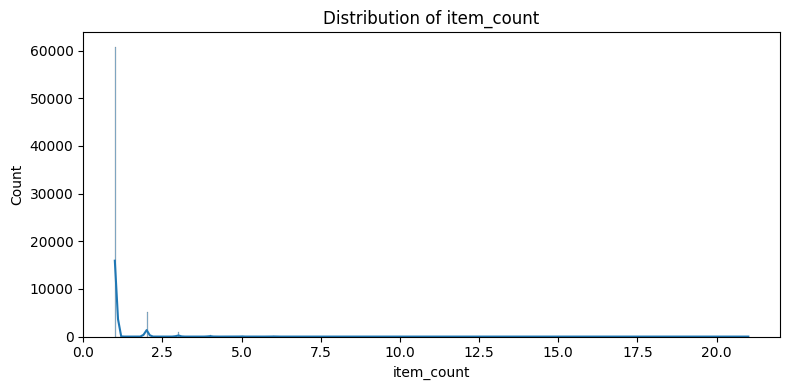

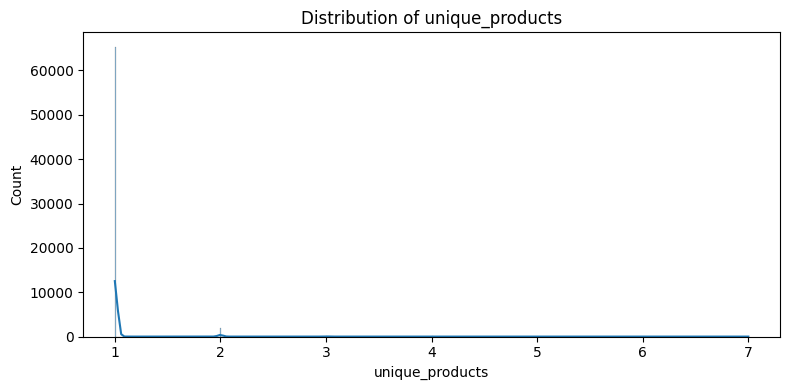

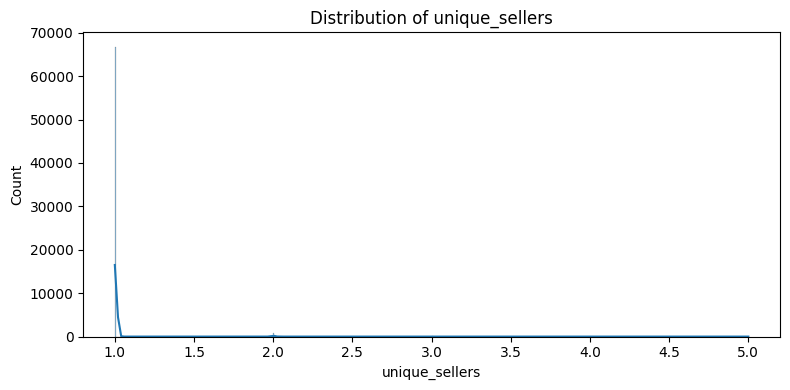

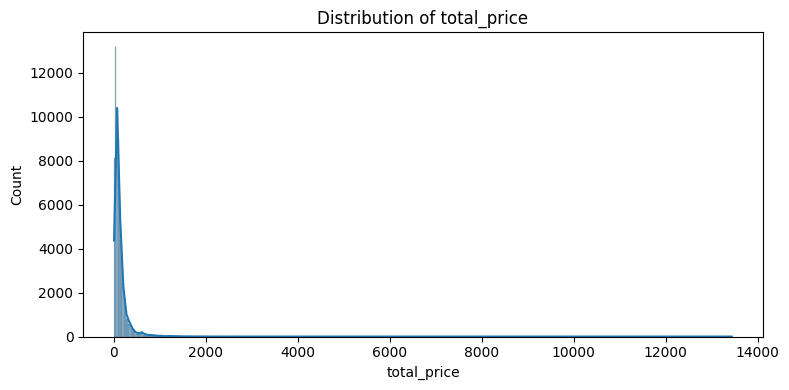

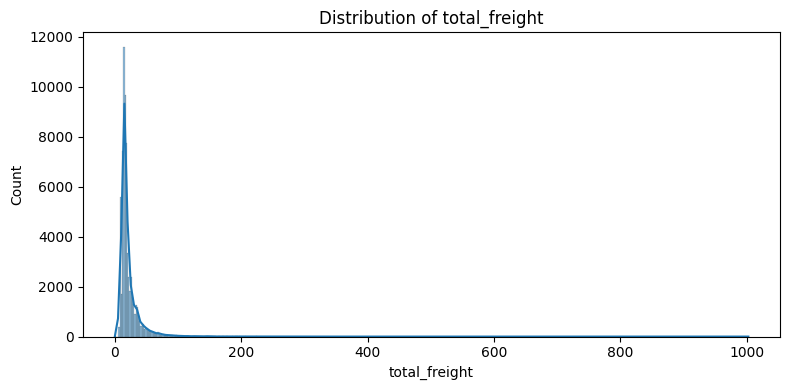

In [17]:
for col in numeric_features[:5]:
    plt.figure(figsize=(8, 4))
    sns.histplot(train[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(
        EDA_DIR / f"distribution_{col}.png",
        bbox_inches="tight")
    plt.show()
    plt.close()

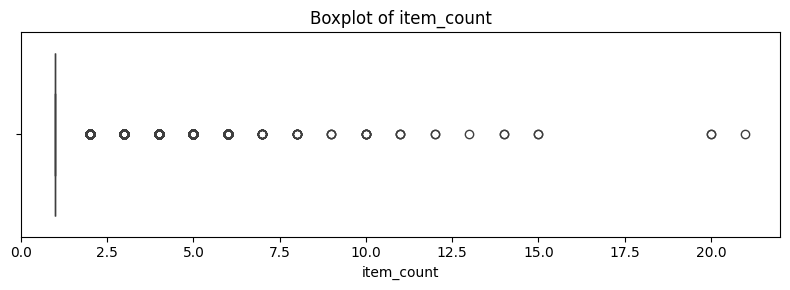

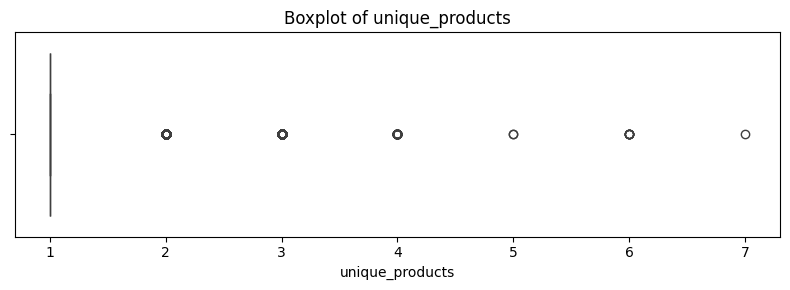

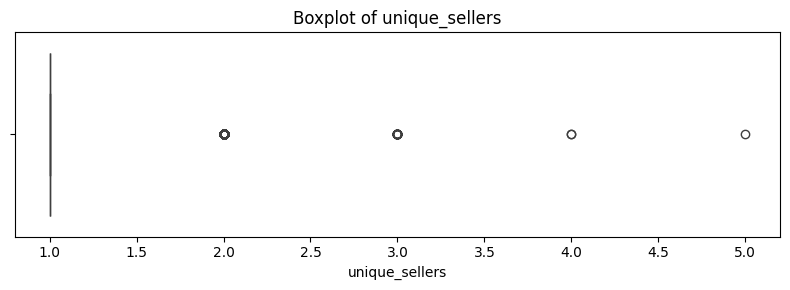

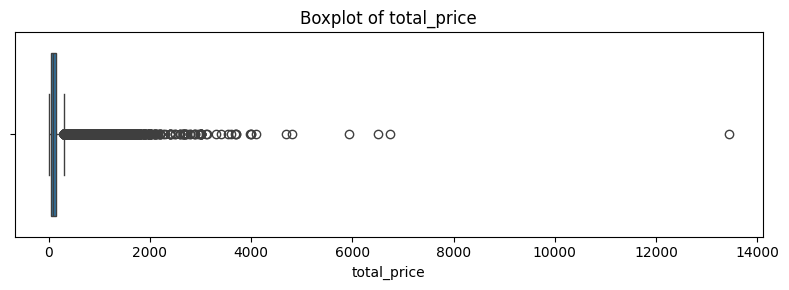

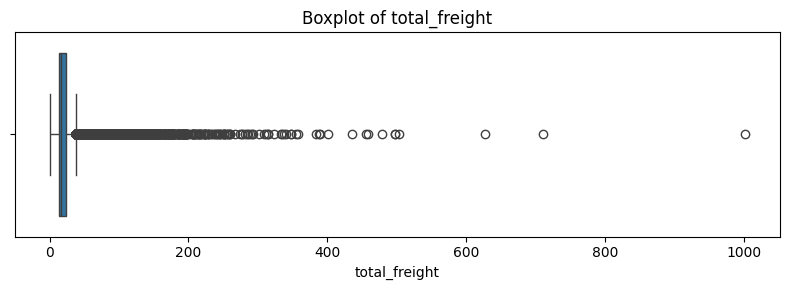

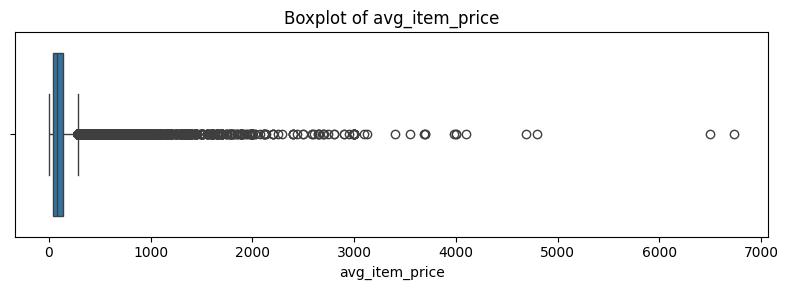

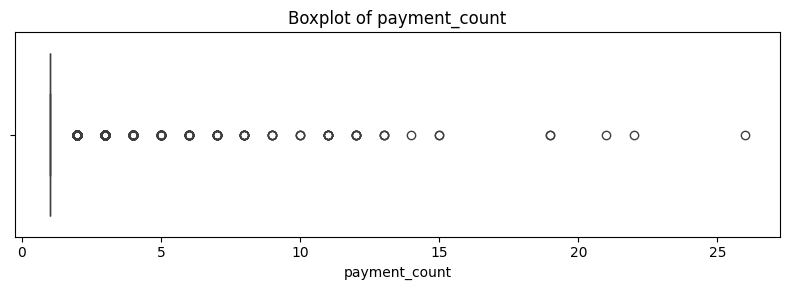

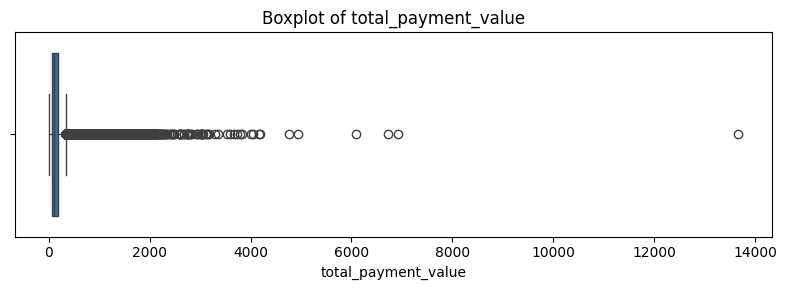

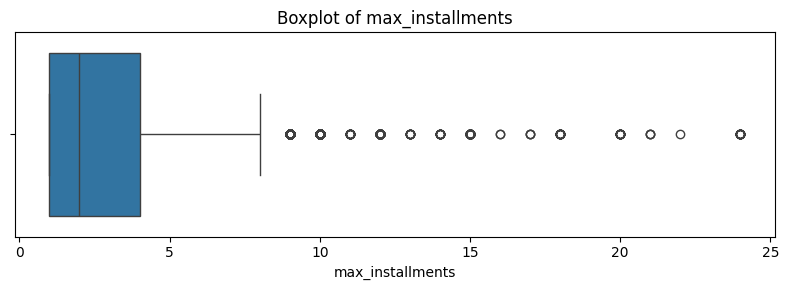

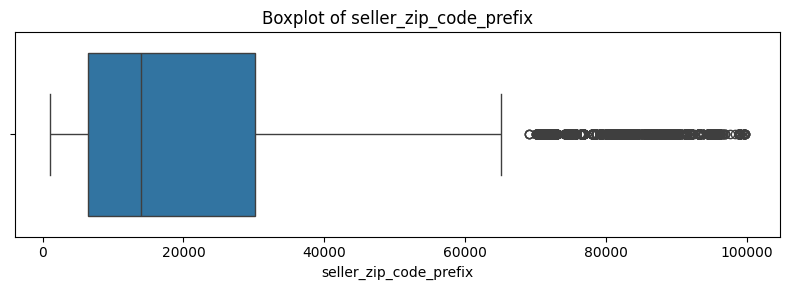

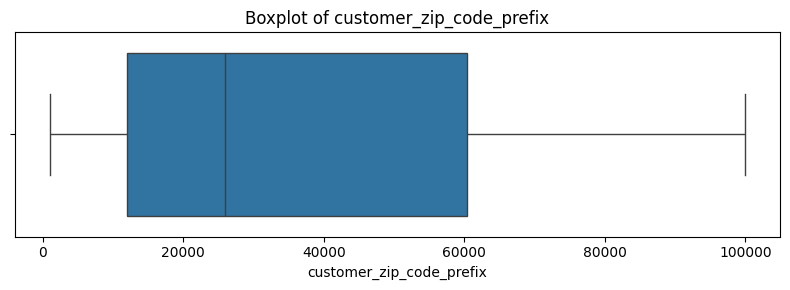

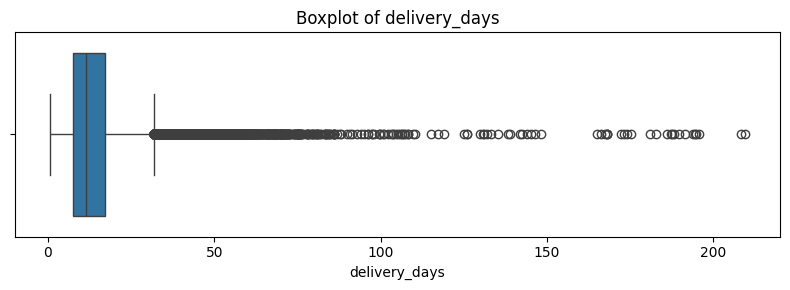

In [18]:
# Outliers
for col in numeric_features:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=train[col]) 
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.savefig(
        EDA_DIR / f"boxplot_{col}.png",
        bbox_inches="tight")
    plt.show()
    plt.close()

In [19]:
outlier_summary = []
for col in numeric_features:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = train[
        (train[col] < lower_bound) |
        (train[col] > upper_bound)]
    outlier_summary.append({
        "feature": col,
        "outlier_count": len(outliers),
        "outlier_percentage": round(len(outliers) / len(train) * 100, 2)})
outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,feature,outlier_count,outlier_percentage
0,item_count,6759,10.01
1,unique_products,2210,3.27
2,unique_sellers,776,1.15
3,total_price,5361,7.94
4,total_freight,6629,9.82
5,avg_item_price,5109,7.57
6,payment_count,2129,3.15
7,total_payment_value,5308,7.86
8,max_installments,4677,6.93
9,seller_zip_code_prefix,10494,15.54


In [20]:
# Categorical Features
categorical_columns = [
    col for col in train.select_dtypes(include=["object"]).columns
    if col not in id_columns]
print("Categorical columns:")
print(categorical_columns)


Categorical columns:
['order_status', 'order_delivered_carrier_date', 'seller_state', 'customer_city', 'customer_state']


C:\Users\rosto\AppData\Local\Temp\ipykernel_11144\674246471.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in train.select_dtypes(include=["object"]).columns


In [21]:
# Cardinality  -- (unique values) --
cardinality = (
    train[categorical_columns]
    .nunique()
    .sort_values(ascending=False))
cardinality

order_delivered_carrier_date    63242
customer_city                    3747
customer_state                     27
seller_state                       22
order_status                        2
dtype: int64

In [22]:
for col in categorical_columns:
    print(f"\n **** {col} **** ")
    print(train[col].value_counts(dropna=False).head(10))


 **** order_status **** 
order_status
delivered    67527
canceled         6
Name: count, dtype: int64

 **** order_delivered_carrier_date **** 
order_delivered_carrier_date
2016-10-14 18:00:00    11
2017-07-26 11:07:51     7
2017-03-21 09:17:46     6
2017-05-24 12:14:23     5
2017-07-19 19:22:35     5
2017-02-06 11:54:29     4
2017-03-23 08:42:41     4
2017-04-27 11:24:46     4
2017-05-09 14:19:21     4
2017-05-23 07:13:36     4
Name: count, dtype: int64

 **** seller_state **** 
seller_state
SP    47865
MG     5631
PR     5357
RJ     2693
SC     2579
RS     1285
DF      585
BA      409
GO      302
ES      252
Name: count, dtype: int64

 **** customer_city **** 
customer_city
sao paulo                9921
rio de janeiro           4780
belo horizonte           1869
brasilia                 1395
curitiba                 1020
porto alegre              975
campinas                  967
salvador                  823
guarulhos                 724
sao bernardo do campo     622
Name: count, d

In [23]:
# Rare Categories
# A category is considered rare if it appears in less than 1% of the training rows.
rare_category_summary = []
for col in categorical_columns:
    frequencies = train[col].value_counts(normalize=True, dropna=False)
    rare_categories = frequencies[frequencies < 0.01]
    rare_category_summary.append({
        "feature": col,
        "rare_category_count": len(rare_categories),
        "rare_row_count": int(train[col].isin(rare_categories.index).sum()),
        "rare_row_percentage": round(
            train[col].isin(rare_categories.index).mean() * 100, 2)})
rare_category_summary = pd.DataFrame(rare_category_summary)
rare_category_summary


,feature,rare_category_count,rare_row_count,rare_row_percentage
0,order_status,1,6,0.01
1,order_delivered_carrier_date,63243,67533,100.00
2,seller_state,16,2123,3.14
3,customer_city,3738,45059,66.72
4,customer_state,14,3934,5.83


In [24]:
label_counts = train["is_late"].value_counts()
print(label_counts)
print("\nPercentage:")
print(train["is_late"].value_counts(normalize=True) * 100)

is_late
0    61436
1     6097
Name: count, dtype: int64

Percentage:
is_late
0    90.971821
1     9.028179
Name: proportion, dtype: float64


In [25]:
# Categorical vs Label
state_late_rate = (
    train.groupby("customer_state")["is_late"]
    .mean()
    .sort_values(ascending=False))
state_late_rate

customer_state
AL    0.278523
MA    0.215328
CE    0.182489
RR    0.172414
SE    0.170732
PI    0.166667
RJ    0.165830
BA    0.149978
PA    0.133705
ES    0.132872
TO    0.131980
PB    0.127027
RN    0.123209
SC    0.119519
PE    0.119069
MS    0.117530
GO    0.095813
RS    0.086656
MT    0.085938
DF    0.079772
MG    0.062977
AP    0.058824
SP    0.055948
PR    0.054320
AM    0.047619
AC    0.045455
RO    0.037838
Name: is_late, dtype: float64

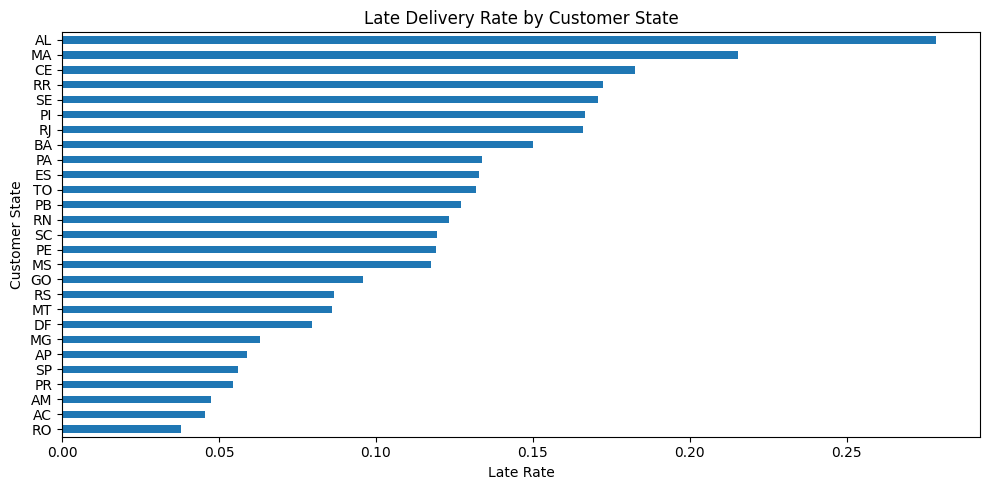

In [26]:
plt.figure(figsize=(10, 5))
state_late_rate.sort_values().plot(kind="barh")
plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Late Rate")
plt.ylabel("Customer State")
plt.tight_layout()
plt.savefig(
    EDA_DIR / "late_rate_by_customer_state.png",
    bbox_inches="tight")
plt.show()
plt.close()


In [27]:
for col in ["customer_state", "seller_state"]:
    if col in train.columns:
        result = (
            train.groupby(col)["is_late"]
            .mean()
            .sort_values(ascending=False))
        print(f"\nLate rate by {col}:")
        print(result)


Late rate by customer_state:
customer_state
AL    0.278523
MA    0.215328
CE    0.182489
RR    0.172414
SE    0.170732
PI    0.166667
RJ    0.165830
BA    0.149978
PA    0.133705
ES    0.132872
TO    0.131980
PB    0.127027
RN    0.123209
SC    0.119519
PE    0.119069
MS    0.117530
GO    0.095813
RS    0.086656
MT    0.085938
DF    0.079772
MG    0.062977
AP    0.058824
SP    0.055948
PR    0.054320
AM    0.047619
AC    0.045455
RO    0.037838
Name: is_late, dtype: float64

Late rate by seller_state:
seller_state
AM    0.666667
MA    0.380952
PA    0.125000
CE    0.125000
RN    0.108696
PB    0.105263
RJ    0.098403
SP    0.098047
PR    0.076909
ES    0.075397
SC    0.065529
BA    0.063570
MG    0.062156
PE    0.061611
DF    0.061538
MT    0.047619
RS    0.042802
GO    0.039735
MS    0.026316
PI    0.000000
RO    0.000000
SE    0.000000
Name: is_late, dtype: float64


In [28]:
# Numerical Feature vs Label
train.groupby("is_late")[numeric_features].mean().T

is_late,0,1
item_count,1.144834,1.114319
unique_products,1.039228,1.022470
unique_sellers,1.012989,1.002624
total_price,134.506741,149.767376
total_freight,21.950632,25.202941
avg_item_price,122.632952,140.374029
payment_count,1.048359,1.040190
total_payment_value,156.496706,175.007633
max_installments,2.959486,3.124672
seller_zip_code_prefix,25137.933199,21511.729047


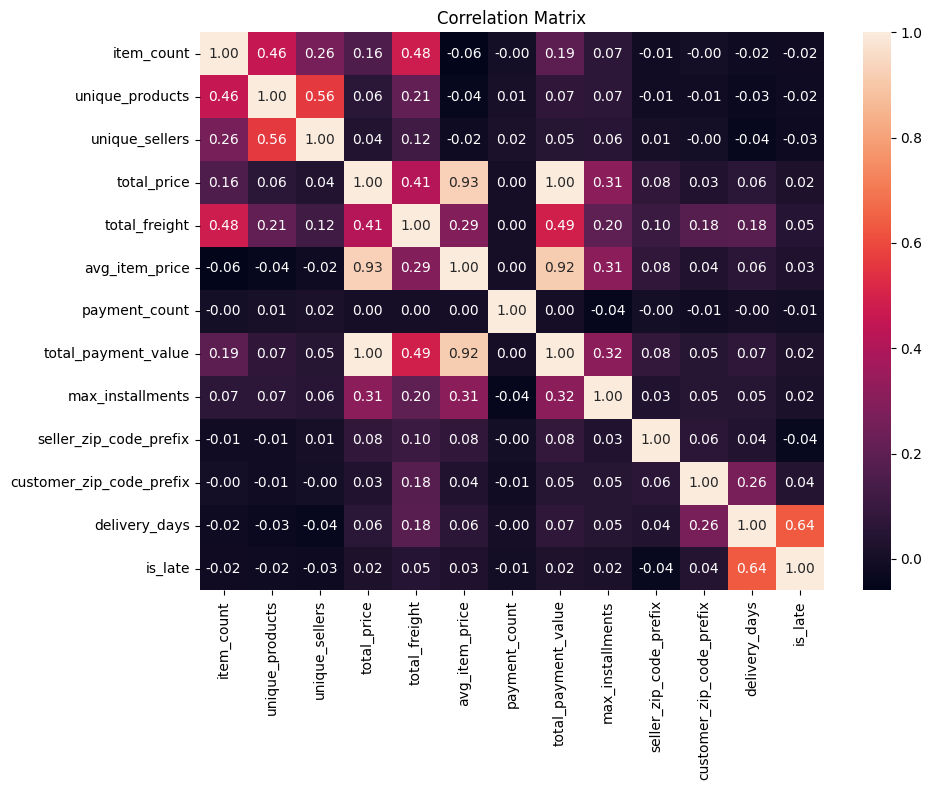

In [29]:
# Correlation
correlation = train[numeric_features + ["is_late"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation,
    annot=True,fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(
    EDA_DIR / "correlation_matrix.png",
    bbox_inches="tight")
plt.show()
plt.close()

In [30]:
# Days of Week
if "order_purchase_timestamp" in train.columns:
    train["purchase_day_of_week"] = (
        train["order_purchase_timestamp"].dt.day_name())
    day_late_rate = (
        train.groupby("purchase_day_of_week")["is_late"]
        .mean())    
    day_late_rate 

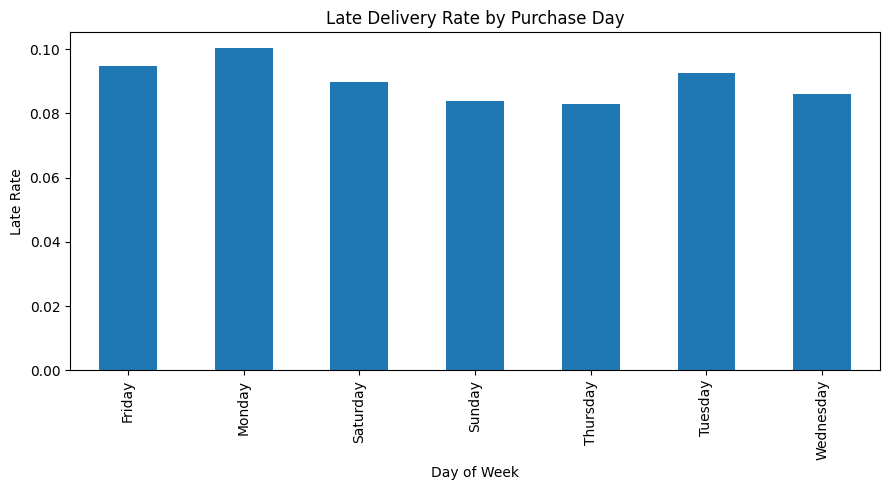

In [31]:
plt.figure(figsize=(9, 5))
day_late_rate.plot(kind="bar")
plt.title("Late Delivery Rate by Purchase Day")
plt.xlabel("Day of Week")
plt.ylabel("Late Rate")
plt.tight_layout()
plt.savefig(
    EDA_DIR / "late_rate_by_day_of_week.png",
    bbox_inches="tight")
plt.show()
plt.close()

In [32]:
# Geographic Analysis
customer_state_analysis = (
    train.groupby("customer_state")["is_late"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False))
customer_state_analysis

,count,mean
customer_state,,
AL,298,0.278523
MA,548,0.215328
CE,948,0.182489
RR,29,0.172414
SE,246,0.170732
PI,348,0.166667
RJ,8967,0.165830
BA,2307,0.149978
PA,718,0.133705


In [33]:
train["purchase_month"] = train["order_purchase_timestamp"].dt.month
monthly_late_rate = (
    train.groupby("purchase_month")["is_late"].mean())
print(monthly_late_rate)

purchase_month
1     0.062284
2     0.134243
3     0.171536
4     0.070236
5     0.036107
6     0.038596
7     0.034349
8     0.033150
9     0.052277
10    0.050548
11    0.143112
12    0.083787
Name: is_late, dtype: float64


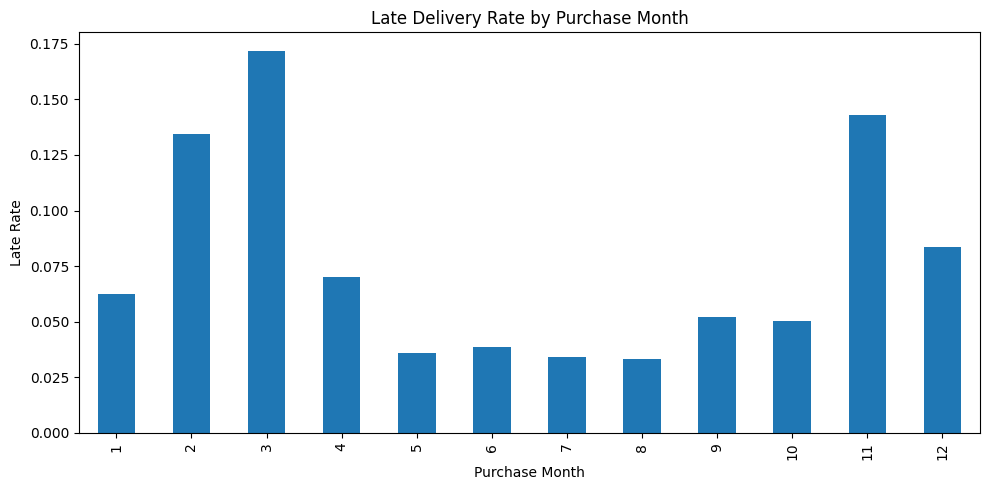

In [34]:
plt.figure(figsize=(10, 5))
monthly_late_rate.plot(kind="bar")
plt.title("Late Delivery Rate by Purchase Month")
plt.xlabel("Purchase Month")
plt.ylabel("Late Rate")
plt.tight_layout()
plt.savefig(
    EDA_DIR / "late_rate_by_month.png",
    bbox_inches="tight")
plt.show()
plt.close()

In [35]:
# NOTE: seller_state added. This was explored during EDA as a natural candidate
# (buyer-seller distance is a plausible driver of delivery delay) but was missing
# from the Notebook 1 ML table until sellers.seller_state was merged in.
# purchase_month / purchase_day_of_week are NOT added here explicitly because
# Notebook 5 already derives them from order_purchase_timestamp, which is
# already in this list -- adding them again would be redundant, not new signal.
selected_features = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_estimated_delivery_date",
    "item_count",
    "unique_products",
    "unique_sellers",
    "total_price",
    "total_freight",
    "avg_item_price",
    "payment_count",
    "total_payment_value",
    "max_installments",
    "customer_zip_code_prefix",
    "customer_state",
    "seller_state"]

In [36]:
# Save selected features
selected_features_df = pd.DataFrame({"feature": selected_features})
selected_features_df.to_csv(
    EDA_DIR / "selected_features.csv",index=False)
print("Selected features saved:", EDA_DIR / "selected_features.csv")


Selected features saved: artifacts\eda\selected_features.csv


## EDA Summary

The EDA was performed on the training dataset only.

- The dataset contains numerical, categorical, ID, and date-related features.
- Missing values were identified and will be handled during preprocessing.
- Numerical features were examined using descriptive statistics, distributions, skewness, and outlier analysis.
- Categorical features were examined for cardinality, frequent categories, and rare categories.
- Relationships between features and the target `is_late` were analyzed.
- Purchase date/time, day-of-week, and month patterns were examined.
- Features based on information available only after delivery were excluded from the selected feature list to reduce leakage risk.

Based on the EDA, the selected features are:

- `order_purchase_timestamp`
- `order_approved_at`
- `order_estimated_delivery_date`
- `item_count`
- `unique_products`
- `unique_sellers`
- `total_price`
- `total_freight`
- `avg_item_price`
- `payment_count`
- `total_payment_value`
- `max_installments`
- `customer_zip_code_prefix`
- `customer_state`  
- `seller_state`


In [37]:
# Save EDA summary
summary_text = """EDA Summary
The EDA was performed on the training dataset only.
- Numerical, categorical, ID, and date-related features were inspected.
- Missing values were identified and will be handled during preprocessing.
- Numerical features were examined using descriptive statistics, distributions, skewness, and outlier analysis.
- Categorical features were examined using cardinality, frequent categories, and rare-category analysis.
- Relationships between features and the target `is_late` were analyzed.
- Purchase date/time features and day-of-week/month patterns were examined.
- Features based on information available only after delivery were excluded from the selected feature list to reduce leakage risk.
Selected features:
""" + "\n".join(f"- {f}" for f in selected_features)
with open(EDA_DIR / "eda_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)
print("EDA summary saved:", EDA_DIR / "eda_summary.txt")
print("\nSaved EDA artifacts:")
for file in sorted(EDA_DIR.iterdir()):
    print(file.name)


EDA summary saved: artifacts\eda\eda_summary.txt

Saved EDA artifacts:
boxplot_avg_item_price.png
boxplot_customer_zip_code_prefix.png
boxplot_delivery_days.png
boxplot_item_count.png
boxplot_max_installments.png
boxplot_payment_count.png
boxplot_seller_zip_code_prefix.png
boxplot_total_freight.png
boxplot_total_payment_value.png
boxplot_total_price.png
boxplot_unique_products.png
boxplot_unique_sellers.png
correlation_matrix.png
distribution_item_count.png
distribution_total_freight.png
distribution_total_price.png
distribution_unique_products.png
distribution_unique_sellers.png
eda_summary.txt
late_rate_by_customer_state.png
late_rate_by_day_of_week.png
late_rate_by_month.png
selected_features.csv
